In [1]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 17.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))   # should show one device

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
from google.colab import userdata

# Make sure no leftover KGAT token is around to hijack auth.
os.environ.pop("KAGGLE_API_TOKEN", None)

# Legacy creds, stripped of any stray whitespace/newlines.
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME").strip()
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY").strip()

# Sanity check (doesn't print the secret):
# a legacy key is a ~32-char hex string, NOT starting with "KGAT_".
k = os.environ["KAGGLE_KEY"]
print("username set:", bool(os.environ["KAGGLE_USERNAME"]))
print("key length:", len(k), "| legacy (not KGAT):", not k.startswith("KGAT_"))

# Download + extract
!kaggle datasets download -d salader/dogs-vs-cats --unzip -p /content/dogs-vs-cats
dataset_path = "/content/dogs-vs-cats"

username set: True
key length: 32 | legacy (not KGAT): True
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [4]:
!kaggle datasets list -s dogs-vs-cats

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         109168        979  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          32087        366  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3328        106  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [5]:
!kaggle datasets download -d salader/dogsVScats --unzip -p /content/dogs-vs-cats
dataset_path = "/content/dogs-vs-cats"
print("Dataset ready at:", dataset_path)

Dataset URL: https://www.kaggle.com/datasets/salader/dogsVScats
License(s): unknown
100% 1.06G/1.06G [00:06<00:00, 187MB/s]

Dataset ready at: /content/dogs-vs-cats


In [6]:
import os
print(os.listdir(dataset_path))              # expect something like ['train', 'test']
print(os.listdir(f"{dataset_path}/train"))   # expect ['cats', 'dogs']

['catsvsdogs', 'train', 'test']
['dogs', 'cats']


In [7]:
import os

train_dir = os.path.join(dataset_path, "train")
test_dir  = os.path.join(dataset_path, "test")

print("Train classes:", os.listdir(train_dir))  # ['dogs', 'cats']
print("Test  classes:", os.listdir(test_dir))

Train classes: ['dogs', 'cats']
Test  classes: ['dogs', 'cats']


In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

In [9]:
# include_top=False  -> drop VGG16's original 1000-class head, we add our own.
# input_shape        -> our images are resized to 150x150 RGB.
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model = Sequential()

model.add(conv_base)              # pretrained feature extractor
model.add(Flatten())              # flatten feature maps -> vector
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))   # binary: cat vs dog

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Freeze VGG16 so ONLY our new Dense head learns. The pretrained
# ImageNet features stay untouched.
conv_base.trainable = False

In [14]:
# Loads images from folders, infers labels from subfolder names (cats/dogs).
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [15]:
# VGG16-scale features work best on normalized inputs.
def process(image, label):
    image = tensorflow.cast(image / 255., tensorflow.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 131ms/step - accuracy: 0.8840 - loss: 0.2686 - val_accuracy: 0.8986 - val_loss: 0.2321
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.9204 - loss: 0.1886 - val_accuracy: 0.9094 - val_loss: 0.2167
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9347 - loss: 0.1592 - val_accuracy: 0.9012 - val_loss: 0.2454
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9457 - loss: 0.1300 - val_accuracy: 0.9126 - val_loss: 0.2183
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9587 - loss: 0.1022 - val_accuracy: 0.9110 - val_loss: 0.2258
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9618 - loss: 0.0922 - val_accuracy: 0.9136 - val_loss: 0.2417
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9760 - loss: 0.0643 - val_accuracy: 0.9092 - val_loss: 0.2637
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.9822 - loss: 0

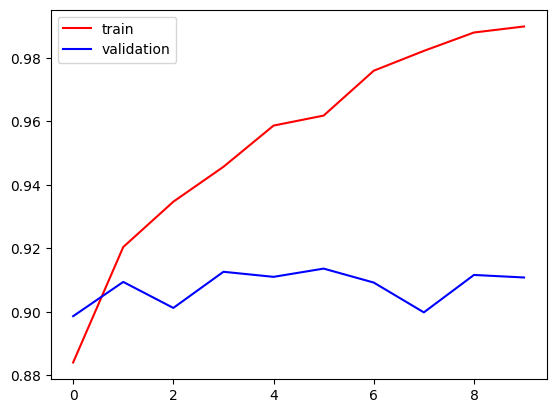

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

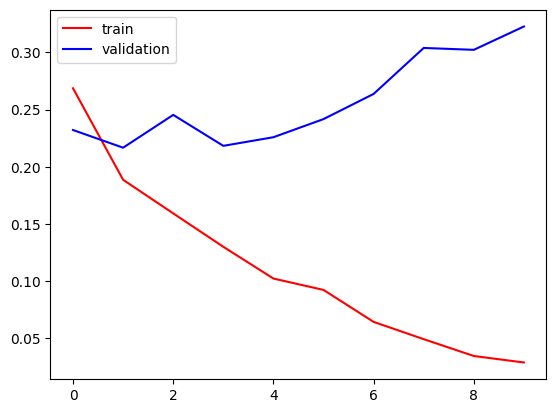

In [19]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

# Version 2 — Feature Extraction WITH Data Augmentation

Same frozen VGG16 backbone and the same `model` object as above — we do **not**
rebuild it. We only change the **training data**: instead of feeding raw images,
we feed randomly augmented ones (flips, zoom, rotation) generated on the fly.

Because no weights were saved to disk, `model` still lives in memory from
Version 1; we just re-fit it on the augmented data. Only the changed cells are
repeated below.

In [20]:
# Augmentation as Keras layers, applied inside the tf.data pipeline.
# This is the current-Keras equivalent of the old shear/zoom/horizontal_flip
# ImageDataGenerator settings.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomRotation(0.1),
])

# Apply augmentation ONLY to the training set (never to validation).
# train_ds is already normalized from Version 1, so we reuse it directly.
train_ds_aug = train_ds.map(
    lambda image, label: (data_augmentation(image, training=True), label)
)

In [21]:
# NOTE: `model` still holds the weights trained in Version 1, so this CONTINUES
# training from there. That's fine for the "reuse the same model" flow you wanted.
# If you'd rather compare augmentation from scratch, just re-run Cell 8 (rebuild
# model) + Cell 10 (freeze) + Cell 13 (compile) before this cell.
history = model.fit(train_ds_aug, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 270ms/step - accuracy: 0.8743 - loss: 0.2933 - val_accuracy: 0.9114 - val_loss: 0.2198
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.8906 - loss: 0.2507 - val_accuracy: 0.9208 - val_loss: 0.1948
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 269ms/step - accuracy: 0.8966 - loss: 0.2344 - val_accuracy: 0.9194 - val_loss: 0.1945
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 274ms/step - accuracy: 0.9018 - loss: 0.2292 - val_accuracy: 0.9006 - val_loss: 0.2310
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.9084 - loss: 0.2194 - val_accuracy: 0.9080 - val_loss: 0.2286
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 274ms/step - accuracy: 0.9046 - loss: 0.2187 - val_accuracy: 0.9182 - val_loss: 0.1987
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 267ms/step - accuracy: 0.9078 - loss: 0.2148 - val_accuracy: 0.9176 - val_loss: 0.1970
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 273ms/step - accuracy: 0.9088 -

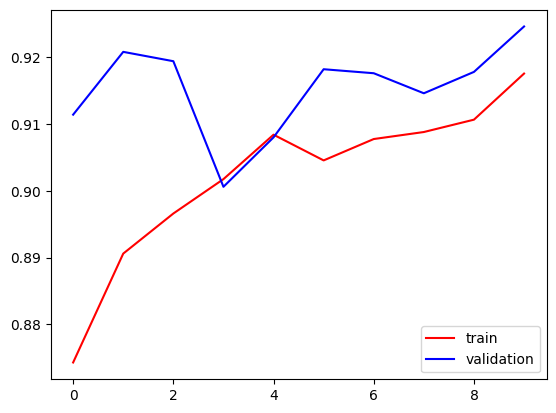

In [22]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

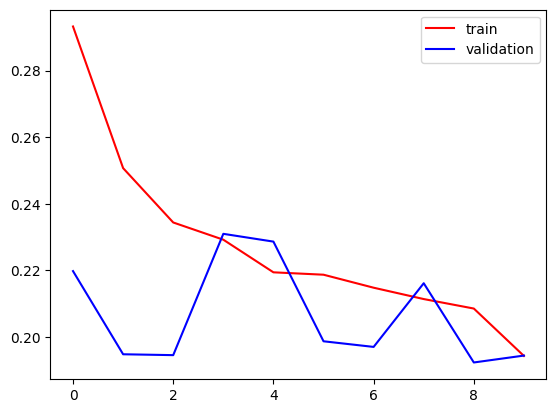

In [23]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

# Version 3 — Fine-Tuning

Now we **unfreeze the top convolutional block (block5)** of VGG16 and train it
together with our classifier head, using a very small learning rate so we nudge
the pretrained weights instead of wrecking them.

We re-declare `conv_base`'s trainable flags and re-declare `model`, then reuse
the same (non-augmented) `train_ds` / `validation_ds` from Version 1.

In [24]:
# Make the base trainable, then selectively freeze everything BEFORE block5.
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':   # from here on, allow training
        set_trainable = True
    layer.trainable = set_trainable

# Confirm which layers are now trainable.
for layer in conv_base.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [25]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [26]:
# Re-declaring gives a fresh classifier head on top of the now partially-unfrozen
# backbone (matches your original finetuning notebook).
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [27]:
# Low LR is critical for fine-tuning so we don't destroy pretrained features.
# (`lr=` was removed in modern Keras -> use `learning_rate=`.)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
# train_ds / validation_ds still exist from Version 1 (normalized, no augmentation).
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 161ms/step - accuracy: 0.9018 - loss: 0.2366 - val_accuracy: 0.9376 - val_loss: 0.1539
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.9473 - loss: 0.1314 - val_accuracy: 0.9468 - val_loss: 0.1319
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.9635 - loss: 0.0931 - val_accuracy: 0.9496 - val_loss: 0.1247
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.9769 - loss: 0.0647 - val_accuracy: 0.9506 - val_loss: 0.1247
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.9855 - loss: 0.0449 - val_accuracy: 0.9466 - val_loss: 0.1353
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.9920 - loss: 0.0286 - val_accuracy: 0.9468 - val_loss: 0.1467
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 156ms/step - accuracy: 0.9954 - loss: 0.0194 - val_accuracy: 0.9516 - val_loss: 0.1419
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.9973 - loss:

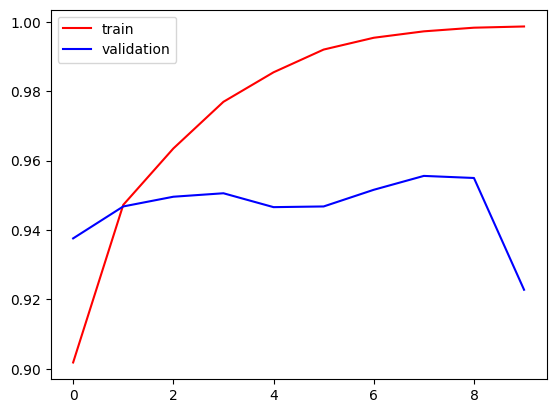

In [29]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

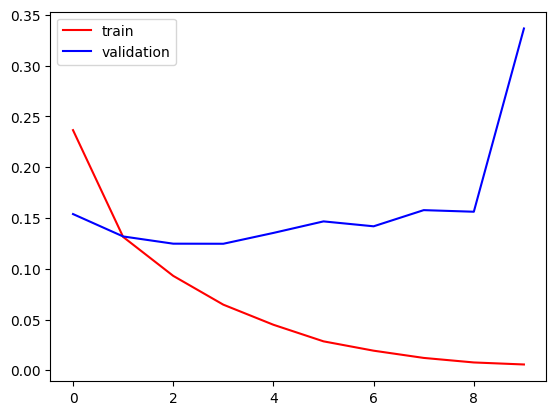

In [30]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()